In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('font', family='Microsoft JhengHei') #chinese
data = pd.read_csv('merge_data.csv')

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6624 entries, 0 to 6623
Data columns (total 51 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   公司編號               6624 non-null   int64  
 1   年份                 6624 non-null   int64  
 2   現金及約當現金            6624 non-null   float64
 3   流動資產               6624 non-null   float64
 4   資產總額               6624 non-null   int64  
 5   流動負債               6624 non-null   float64
 6   負債總額               6624 non-null   int64  
 7   普通股股本              6624 non-null   int64  
 8   股本                 6624 non-null   int64  
 9   資本公積合計             6624 non-null   int64  
 10  保留盈餘               6624 non-null   int64  
 11  股東權益總額             6624 non-null   int64  
 12  營業收入淨額             6624 non-null   float64
 13  營業成本               6624 non-null   float64
 14  營業毛利               6624 non-null   float64
 15  營業費用               6624 non-null   float64
 16  營運資金               6624 

In [3]:
pd.set_option('display.float_format', '{:.2f}'.format)
data.describe().T

,count,mean,std,min,25%,50%,75%,max
公司編號,6624.00,3592.26,2199.89,1103.00,2014.00,2633.00,4942.00,9958.00
年份,6624.00,2019.06,3.12,2014.00,2016.00,2019.00,2022.00,2024.00
現金及約當現金,6624.00,2030568.19,6681041.89,1125.00,319313.75,700943.50,1517210.50,149427959.00
流動資產,6624.00,8676515.57,29273748.10,15260.00,1446379.25,2779874.00,6561823.75,683292033.00
資產總額,6624.00,18772394.16,71548731.98,17267.00,2763590.00,5434440.50,12428527.25,1657801534.00
流動負債,6624.00,5895339.38,28374650.79,776.00,654168.00,1491492.00,3770967.75,793421493.00
負債總額,6624.00,11550074.48,62372827.08,4946.00,944547.25,2295347.00,5883270.00,1607622209.00
普通股股本,6624.00,3387310.89,7638767.97,142719.00,870909.50,1489517.50,3004308.50,105596201.00
股本,6624.00,3399694.15,7709701.07,157600.00,875460.00,1490550.00,3005579.00,105596201.00
資本公積合計,6624.00,1190792.65,5304743.16,-207088.00,59144.75,305537.50,878949.75,105919710.00


### Data Describe 

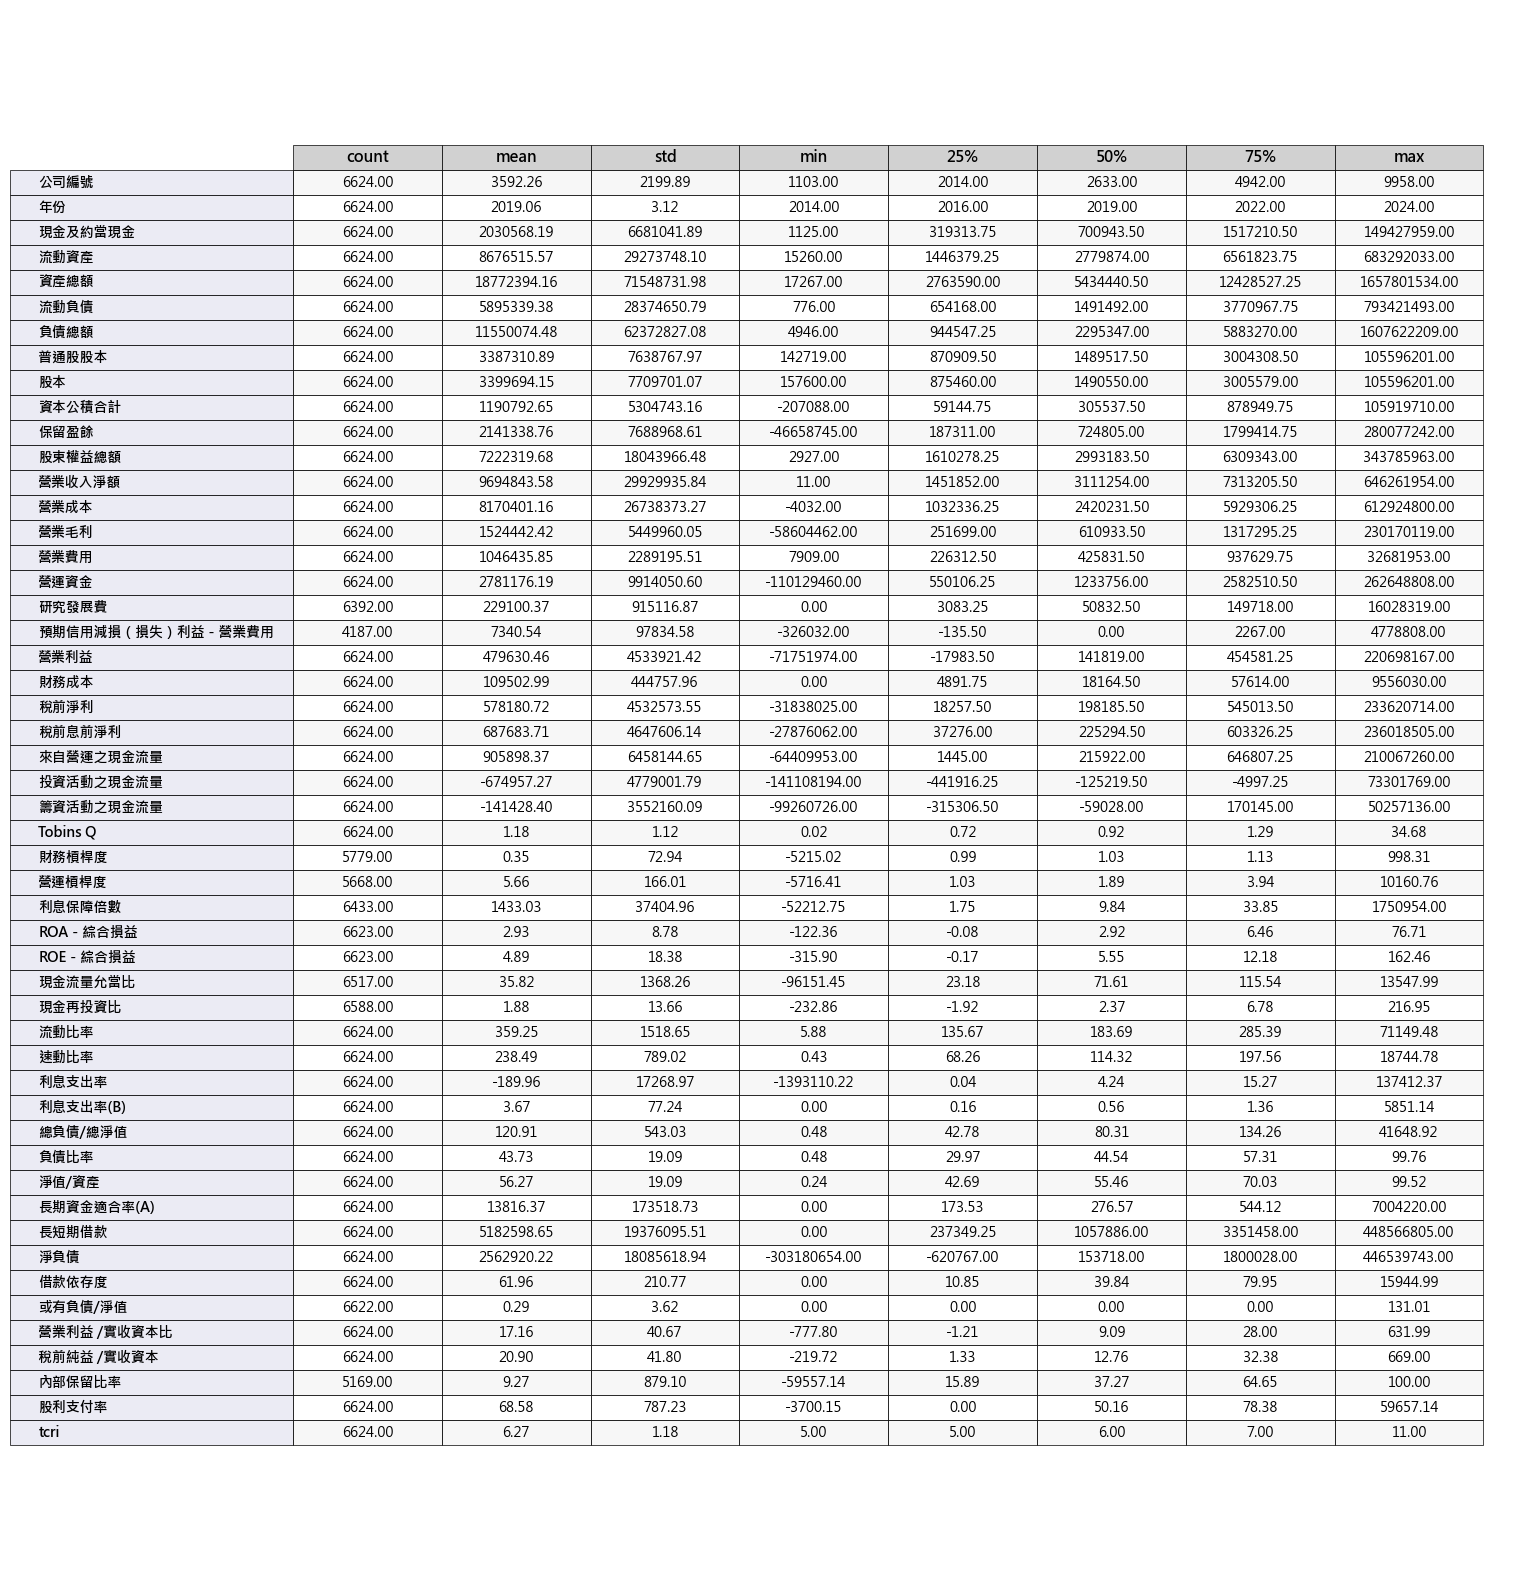

In [4]:
desc = data.describe().T

desc_formatted = desc.copy()
for col in desc_formatted.columns:
    desc_formatted[col] = desc_formatted[col].apply(lambda x: f'{x:.2f}' if pd.notnull(x) else '')

plt.figure(figsize=(16, max(6, len(desc_formatted) * 0.4)))

tbl = plt.table(cellText=desc_formatted.values,
               rowLabels=desc_formatted.index,
               colLabels=desc_formatted.columns,
               loc='center',
               cellLoc='center',
               colWidths=[0.12] * len(desc_formatted.columns),
               edges='closed')

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)

for key, cell in tbl.get_celld().items():
    row, col = key
    
    cell.set_edgecolor('black')
    cell.set_linewidth(0.5)
    
    if row == 0: 
        cell.set_facecolor([0.8, 0.8, 0.8, 0.9]) 
        cell.set_text_props(weight='bold', size=11)
    elif col == -1: 
        cell.set_facecolor([0.9, 0.9, 0.95, 0.8])  
        cell.set_text_props(weight='bold', size=10)
    else:
        if row % 2 == 1:
            cell.set_facecolor([0.95, 0.95, 0.95, 0.6])  
        else:
            cell.set_facecolor([1, 1, 1, 0.8]) 
        cell.set_text_props(size=10)

plt.axis('off')
fig = plt.gcf()
fig.patch.set_alpha(0.0)
ax = plt.gca()
ax.set_facecolor('none')

plt.savefig('data_describe_transparent_2decimal.png', 
            transparent=True, 
            bbox_inches='tight', 
            dpi=300, 
            pad_inches=0.1,
            facecolor='none',
            edgecolor='none')

plt.show()

### Data Type

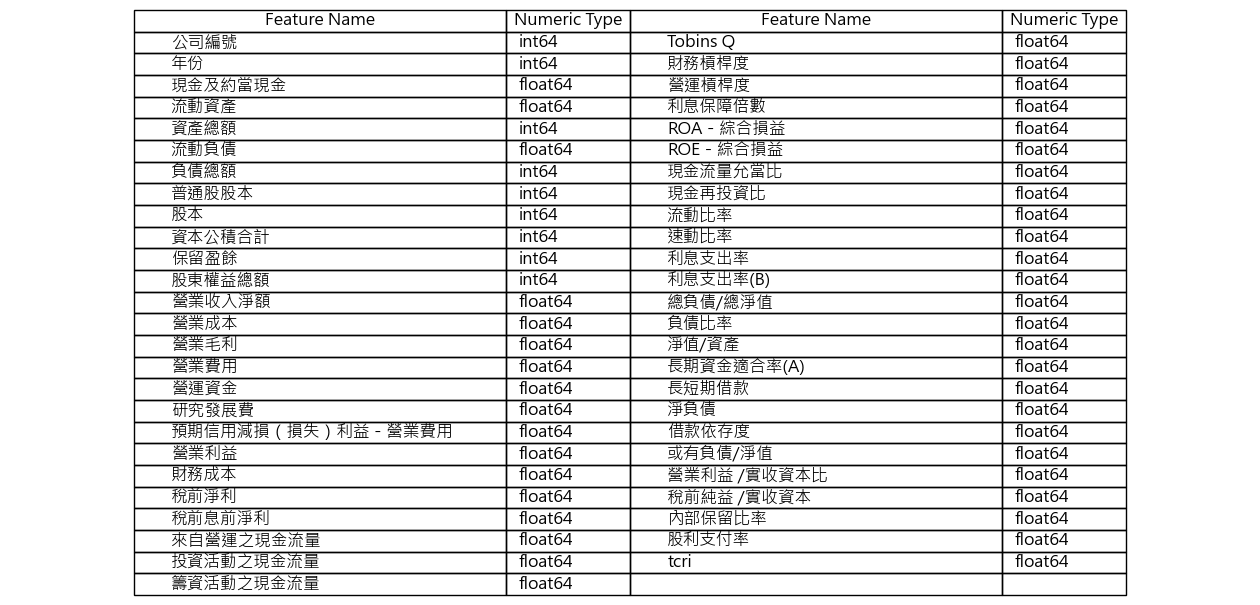

In [5]:
dtype_df = pd.DataFrame({
    'Feature': data.columns,
    'Data_Type': data.dtypes.astype(str)
})

def extract_numeric_type(dtype_str):
    if 'float' in dtype_str:
        return 'float64'
    elif 'int' in dtype_str:
        return 'int64'
    elif 'object' in dtype_str:
        return 'object'
    elif 'bool' in dtype_str:
        return 'bool'
    else:
        return dtype_str

dtype_df['Numeric_Type'] = dtype_df['Data_Type'].apply(extract_numeric_type)

total_features = len(dtype_df)
split_index = (total_features + 1) // 2

left_features = dtype_df.iloc[:split_index].copy()
right_features = dtype_df.iloc[split_index:].copy()

max_length = max(len(left_features), len(right_features))
while len(left_features) < max_length:
    left_features = pd.concat([left_features, pd.DataFrame([{'Feature': '', 'Numeric_Type': ''}])], ignore_index=True)
while len(right_features) < max_length:
    right_features = pd.concat([right_features, pd.DataFrame([{'Feature': '', 'Numeric_Type': ''}])], ignore_index=True)

cell_text = []
for i in range(max_length):
    left_row = left_features.iloc[i]
    right_row = right_features.iloc[i]
    cell_text.append([
        left_row['Feature'],
        left_row['Numeric_Type'],
        right_row['Feature'], 
        right_row['Numeric_Type']
    ])


plt.figure(figsize=(16, max(6, max_length * 0.25)))
table = plt.table(cellText=cell_text,
                 colLabels=['Feature Name', 'Numeric Type', 'Feature Name', 'Numeric Type'],
                 loc='center',
                 cellLoc='left',
                 colWidths=[0.3, 0.1, 0.3, 0.1]
                 )

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.3)

for i in range(4):
    if i < 2:
        table[(0, i)].set_facecolor('none')  
    else:
        table[(0, i)].set_facecolor('none') 

plt.axis('off')

fig = plt.gcf()
fig.patch.set_alpha(0.0)  
ax = plt.gca()
ax.set_facecolor('none') 

for key, cell in table.get_celld().items():
    if key[0] > 0:  
        cell.set_facecolor('none')

plt.savefig('feature_data_types.png', 
            transparent=True, 
            bbox_inches='tight', 
            dpi=300, 
            pad_inches=0.1,
            facecolor='none',   
            edgecolor='none')   

### Missing Map

         Variable  Missing Count  Missing Percentage
預期信用減損（損失）利益－營業費用           2437               36.79
           內部保留比率           1455               21.97
            營運槓桿度            956               14.43
            財務槓桿度            845               12.76
            研究發展費            232                3.50
           利息保障倍數            191                2.88
          現金流量允當比            107                1.62
           現金再投資比             36                0.54
          或有負債/淨值              2                0.03
         ROA－綜合損益              1                0.02
         ROE－綜合損益              1                0.02

Target variable (tcri) missing: 0 (0.00%)


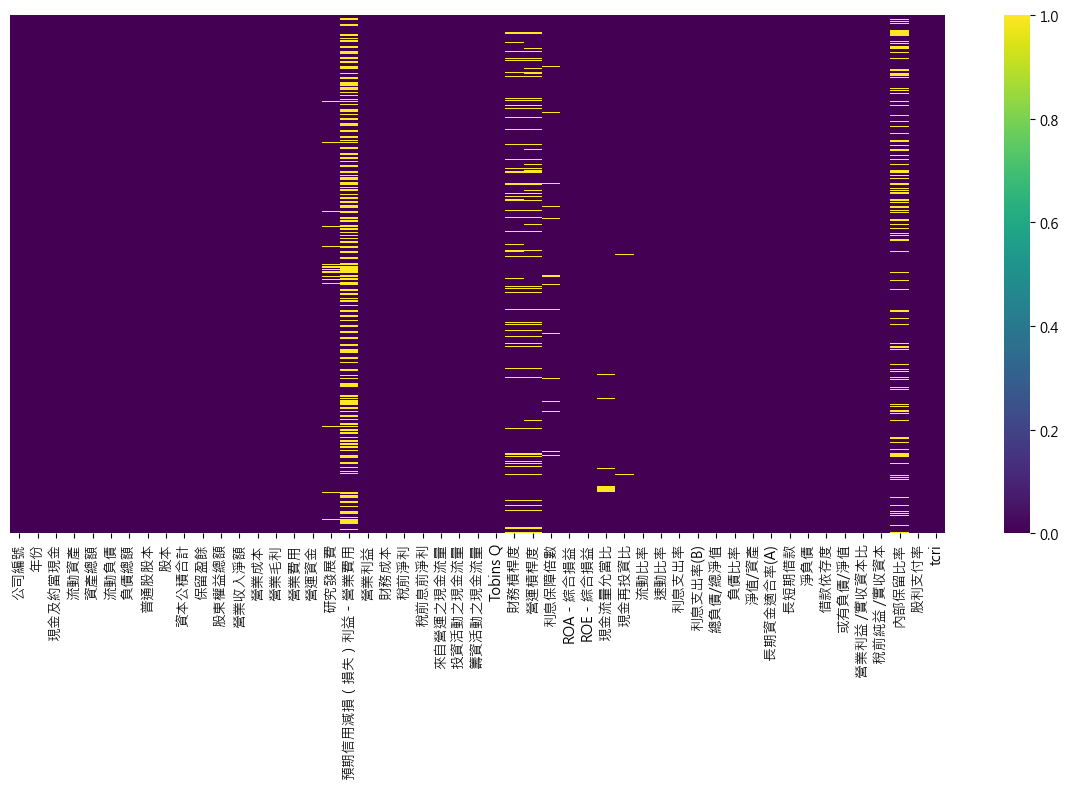

In [6]:
import seaborn as sns
import matplotlib
matplotlib.rc('font', family='Microsoft JhengHei')
# Missing values analysis

missing_data = data.isnull().sum()
missing_percentage = (data.isnull().sum() / len(data)) * 100

missing_df = pd.DataFrame({
    'Variable': missing_data.index,
    'Missing Count': missing_data.values,
    'Missing Percentage': missing_percentage.values
})

# show missing values
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df.to_string(index=False))

# Target variable missing values
target_missing = data['tcri'].isnull().sum()
print(f"\nTarget variable (tcri) missing: {target_missing} ({target_missing/len(data)*100:.2f}%)")

# Visualize missing values
plt.figure(figsize=(12, 8))
sns.heatmap(data.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.tight_layout()
plt.savefig('missing_heat.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

### Missing Value

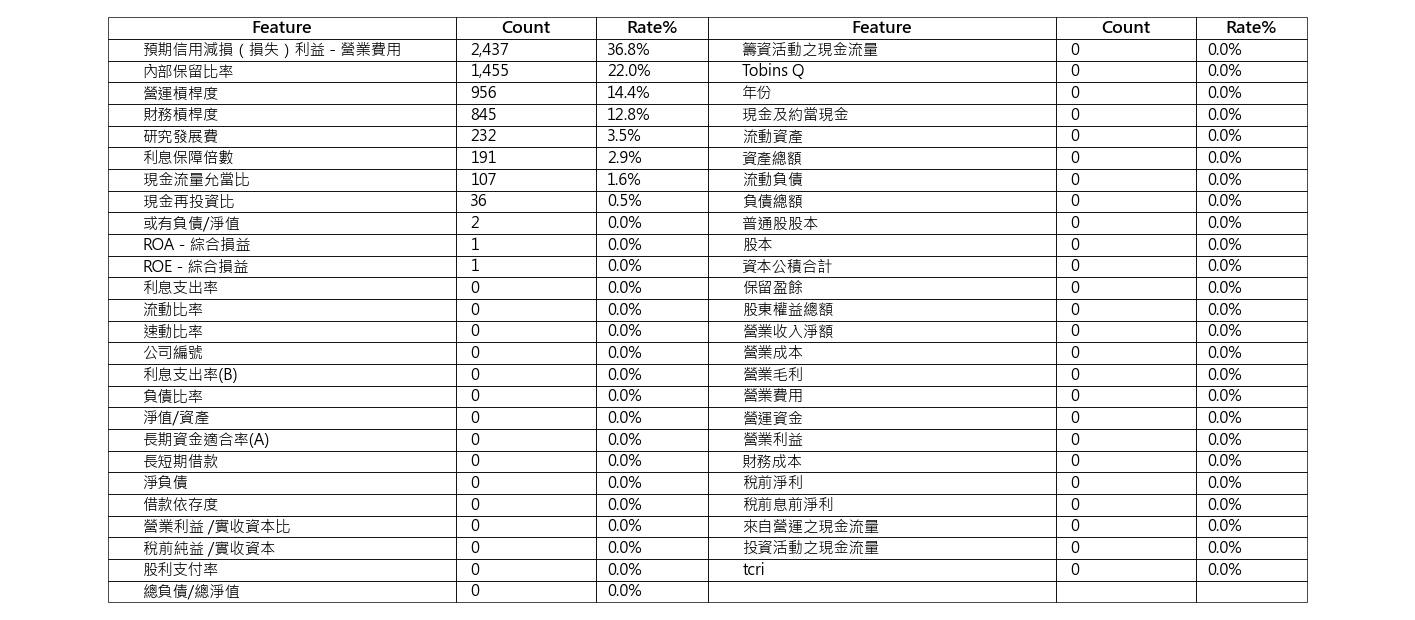

In [7]:
missing_count = data.isnull().sum()
missing_percentage = (data.isnull().sum() / len(data)) * 100

missing_df = pd.DataFrame({
    'Feature': data.columns,
    'Missing_Count': missing_count,
    'Missing_Rate (%)': missing_percentage
})

missing_df_sorted = missing_df.sort_values('Missing_Count', ascending=False)

total_features = len(missing_df_sorted)
split_index = (total_features + 1) // 2

left_features = missing_df_sorted.iloc[:split_index].copy()
right_features = missing_df_sorted.iloc[split_index:].copy()

max_length = max(len(left_features), len(right_features))
while len(left_features) < max_length:
    left_features = pd.concat([left_features, pd.DataFrame([{'Feature': '', 'Missing_Count': '', 'Missing_Rate (%)': ''}])], ignore_index=True)
while len(right_features) < max_length:
    right_features = pd.concat([right_features, pd.DataFrame([{'Feature': '', 'Missing_Count': '', 'Missing_Rate (%)': ''}])], ignore_index=True)

cell_text = []
for i in range(max_length):
    left_row = left_features.iloc[i]
    right_row = right_features.iloc[i]
    cell_text.append([
        left_row['Feature'],
        f"{left_row['Missing_Count']:,}" if left_row['Missing_Count'] != '' else '',
        f"{left_row['Missing_Rate (%)']:.1f}%" if left_row['Missing_Rate (%)'] != '' else '',
        right_row['Feature'],
        f"{right_row['Missing_Count']:,}" if right_row['Missing_Count'] != '' else '',
        f"{right_row['Missing_Rate (%)']:.1f}%" if right_row['Missing_Rate (%)'] != '' else ''
    ])

plt.figure(figsize=(18, max(6, max_length * 0.3)))
table = plt.table(cellText=cell_text,
                 colLabels=['Feature', 'Count', 'Rate%', 'Feature', 'Count', 'Rate%'],
                 loc='center',
                 cellLoc='left',
                 colWidths=[0.25, 0.1, 0.08, 0.25, 0.1, 0.08],
                 edges='closed')

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.3)

for key, cell in table.get_celld().items():
    cell.set_facecolor('none')
    cell.set_edgecolor('black')
    cell.set_linewidth(0.5)
    if key[0] == 0:  
        cell.set_text_props(weight='bold', size=12)
    else:
        cell.set_text_props(size=11)

plt.axis('off')
fig = plt.gcf()
fig.patch.set_alpha(0.0)
ax = plt.gca()
ax.set_facecolor('none')

plt.savefig('missing_values_sorted_two_columns.png', 
            transparent=True, 
            bbox_inches='tight', 
            dpi=300, 
            pad_inches=0.1,
            facecolor='none',
            edgecolor='none')
plt.show()

### Correlation

In [8]:
correlation_matrix = data.select_dtypes(include=[np.number]).corr()

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = abs(correlation_matrix.iloc[i, j])
        if corr_value > 0.5:  # cor
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                corr_value
            ))

high_corr_pairs.sort(key=lambda x: x[2], reverse=True)

for pair in high_corr_pairs[:50]:  # show 30
    print(f"{pair[0]} vs {pair[1]}: {pair[2]:.3f}")

負債比率 vs 淨值/資產: 1.000
普通股股本 vs 股本: 0.998
內部保留比率 vs 股利支付率: 0.997
稅前淨利 vs 稅前息前淨利: 0.996
營業收入淨額 vs 營業成本: 0.988
資產總額 vs 負債總額: 0.973
營業利益 vs 稅前息前淨利: 0.948
總負債/總淨值 vs 借款依存度: 0.945
營業利益 vs 稅前淨利: 0.945
流動資產 vs 流動負債: 0.941
營業毛利 vs 營業利益: 0.911
營業毛利 vs 稅前息前淨利: 0.898
長短期借款 vs 淨負債: 0.891
財務成本 vs 長短期借款: 0.886
營業毛利 vs 稅前淨利: 0.878
ROA－綜合損益 vs ROE－綜合損益: 0.877
營業利益 /實收資本比 vs 稅前純益 /實收資本: 0.876
普通股股本 vs 股東權益總額: 0.873
股本 vs 股東權益總額: 0.867
營業毛利 vs 來自營運之現金流量: 0.842
營業收入淨額 vs 營業費用: 0.822
資本公積合計 vs 股東權益總額: 0.816
營業費用 vs 研究發展費: 0.811
營業成本 vs 營業費用: 0.801
保留盈餘 vs 股東權益總額: 0.787
現金及約當現金 vs 股東權益總額: 0.784
營業利益 vs 來自營運之現金流量: 0.781
現金及約當現金 vs 營業收入淨額: 0.764
現金及約當現金 vs 資產總額: 0.759
資本公積合計 vs 研究發展費: 0.759
流動資產 vs 資產總額: 0.745
股本 vs 研究發展費: 0.744
普通股股本 vs 研究發展費: 0.744
股東權益總額 vs 營業費用: 0.743
稅前息前淨利 vs 來自營運之現金流量: 0.742
現金及約當現金 vs 營業費用: 0.741
普通股股本 vs 營業收入淨額: 0.740
流動比率 vs 速動比率: 0.739
股本 vs 營業收入淨額: 0.734
股東權益總額 vs 營業收入淨額: 0.734
普通股股本 vs 營業費用: 0.730
現金及約當現金 vs 營業成本: 0.727
財務成本 vs 淨負債: 0.727
股本 vs 營業費用: 0.724
稅前淨利 vs 來自營運之現金流量: 0.724

### Heat Map

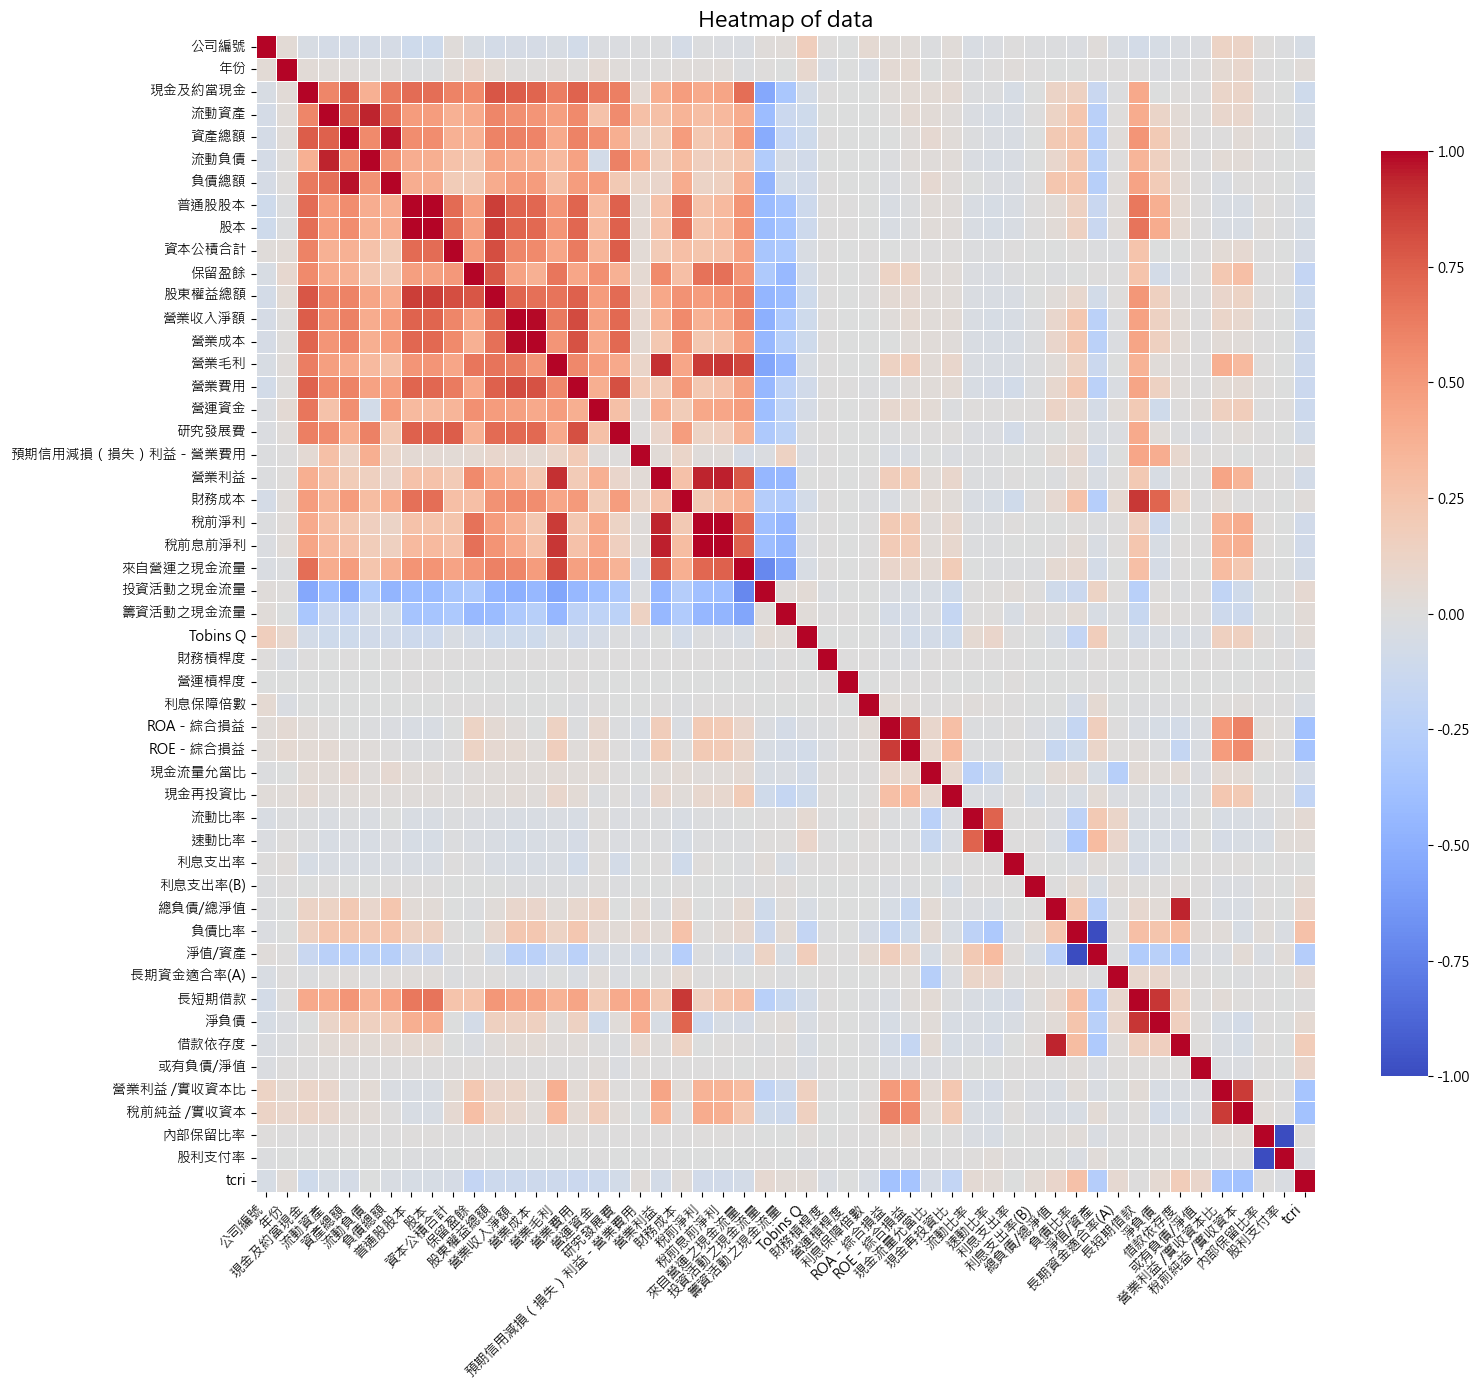

In [9]:
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # 使用支援負號的字體
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, 
           annot=False, 
           cmap='coolwarm', 
           center=0,
           linewidths=0.5,
           cbar_kws={"shrink": 0.8})
plt.title('Heatmap of data', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('merged_heat.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

### Histogram

 51 features


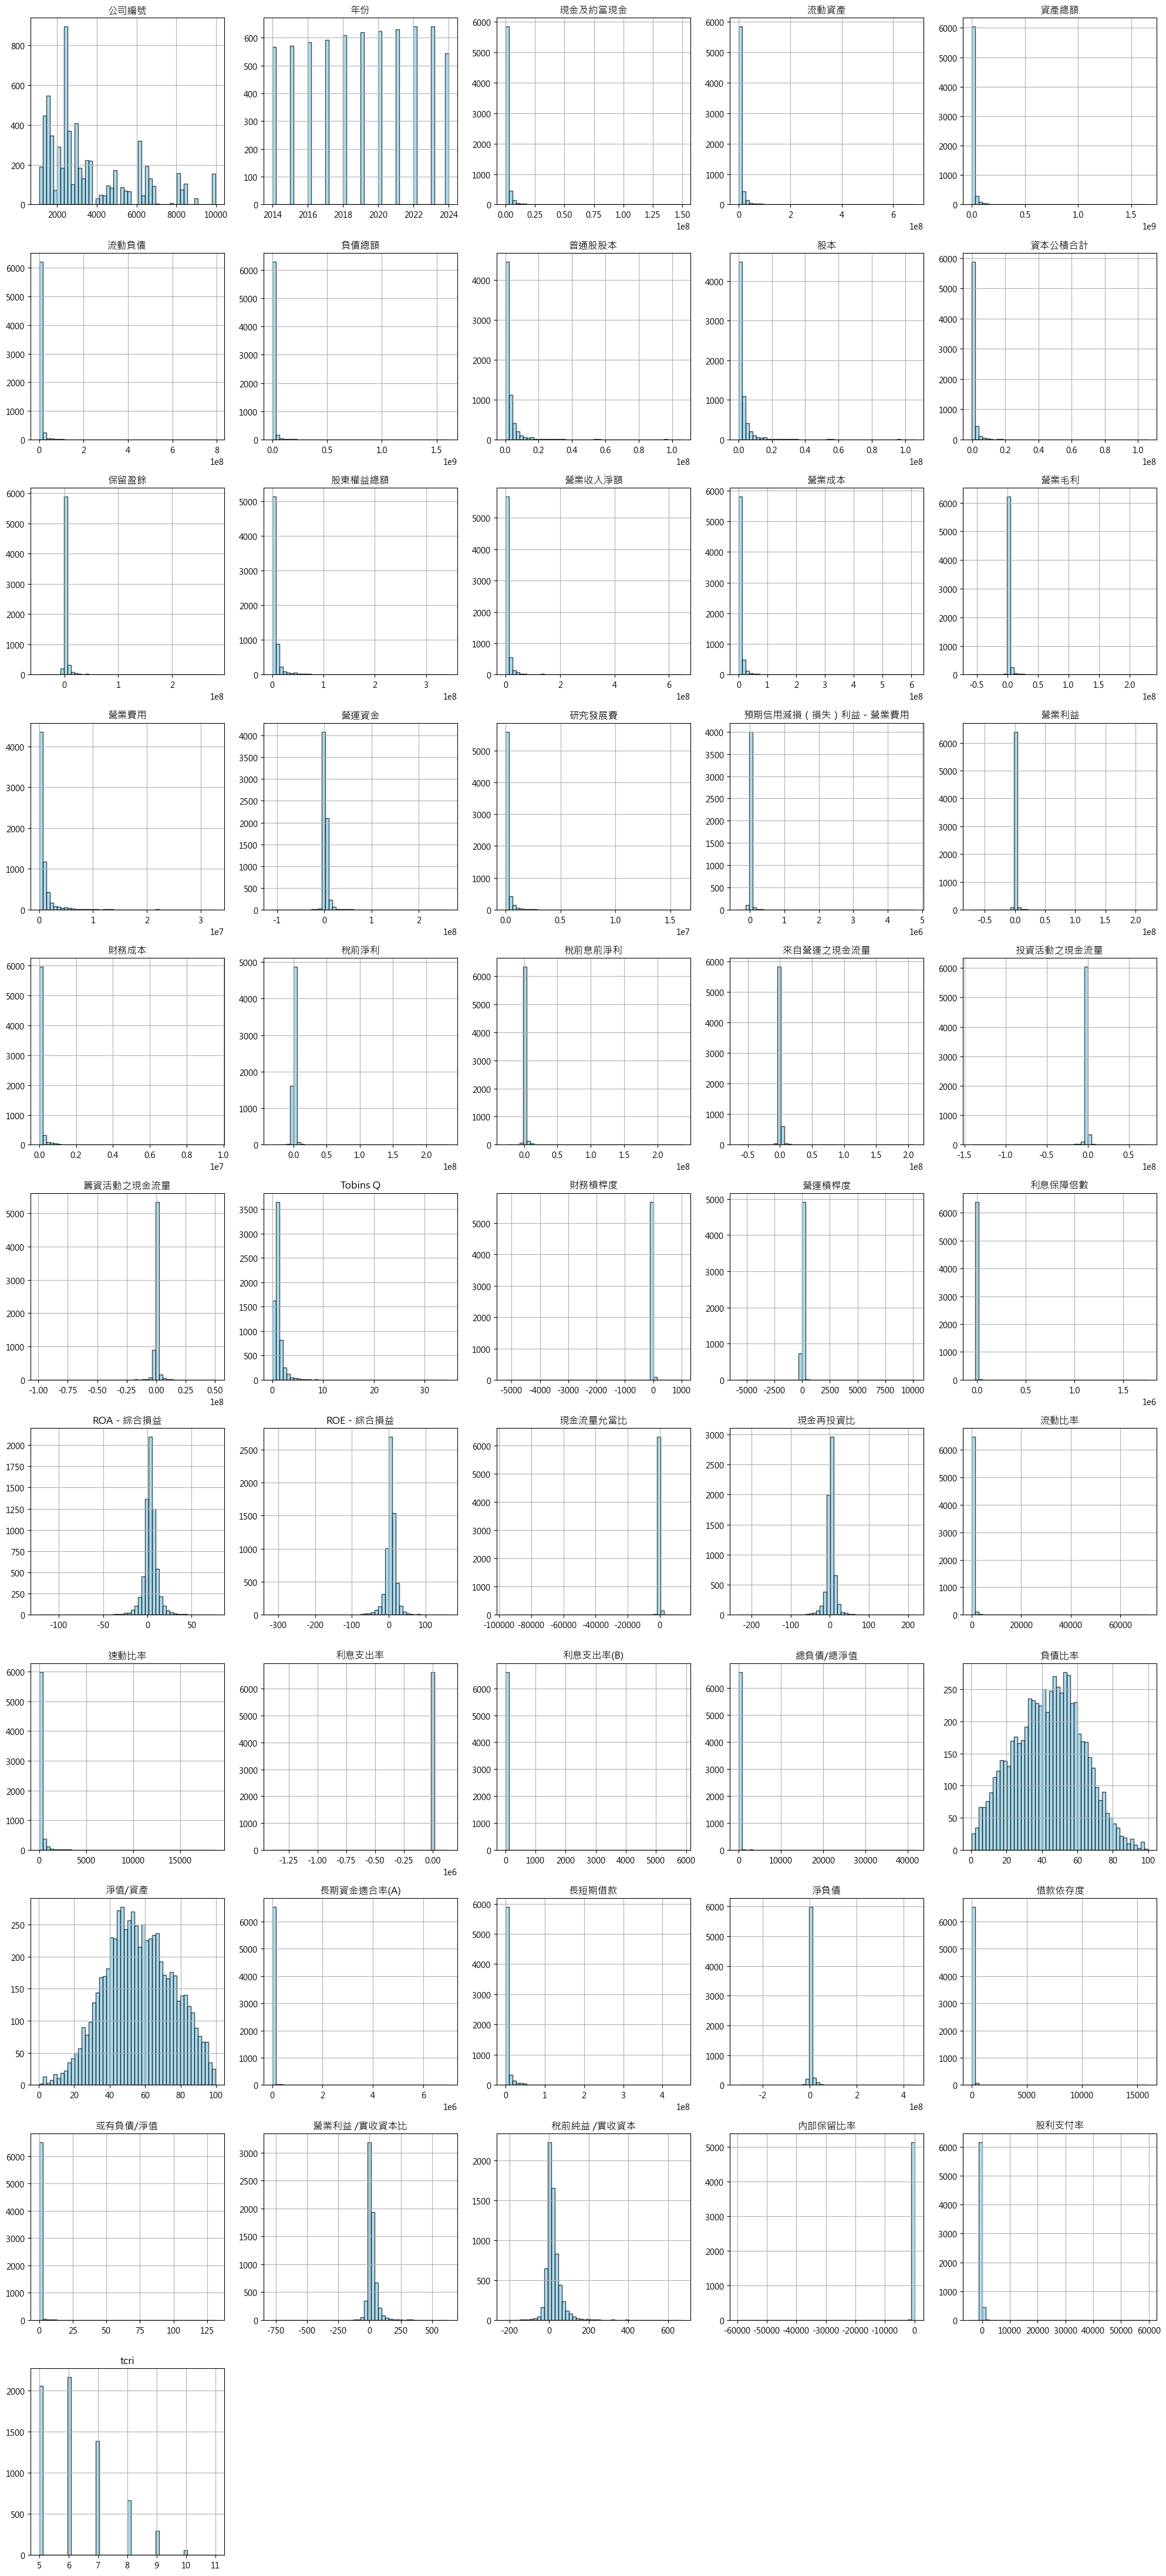

In [11]:
print(f" {len(data.columns)} features")

n_features = len(data.columns)
n_cols = 5 
n_rows = (n_features + n_cols - 1) // n_cols  


data.hist(
    figsize=(20, 4 * n_rows), 
    bins=50,
    color='skyblue',
    edgecolor='black',
    alpha=0.7,
    layout=(n_rows, n_cols)
)

plt.tight_layout()
plt.savefig('histogram.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

C:\Users\jack9\AppData\Local\Temp\ipykernel_2188\4230079111.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  log_data = data.applymap(lambda x: np.log(x + 1) if x > 0 else np.nan)


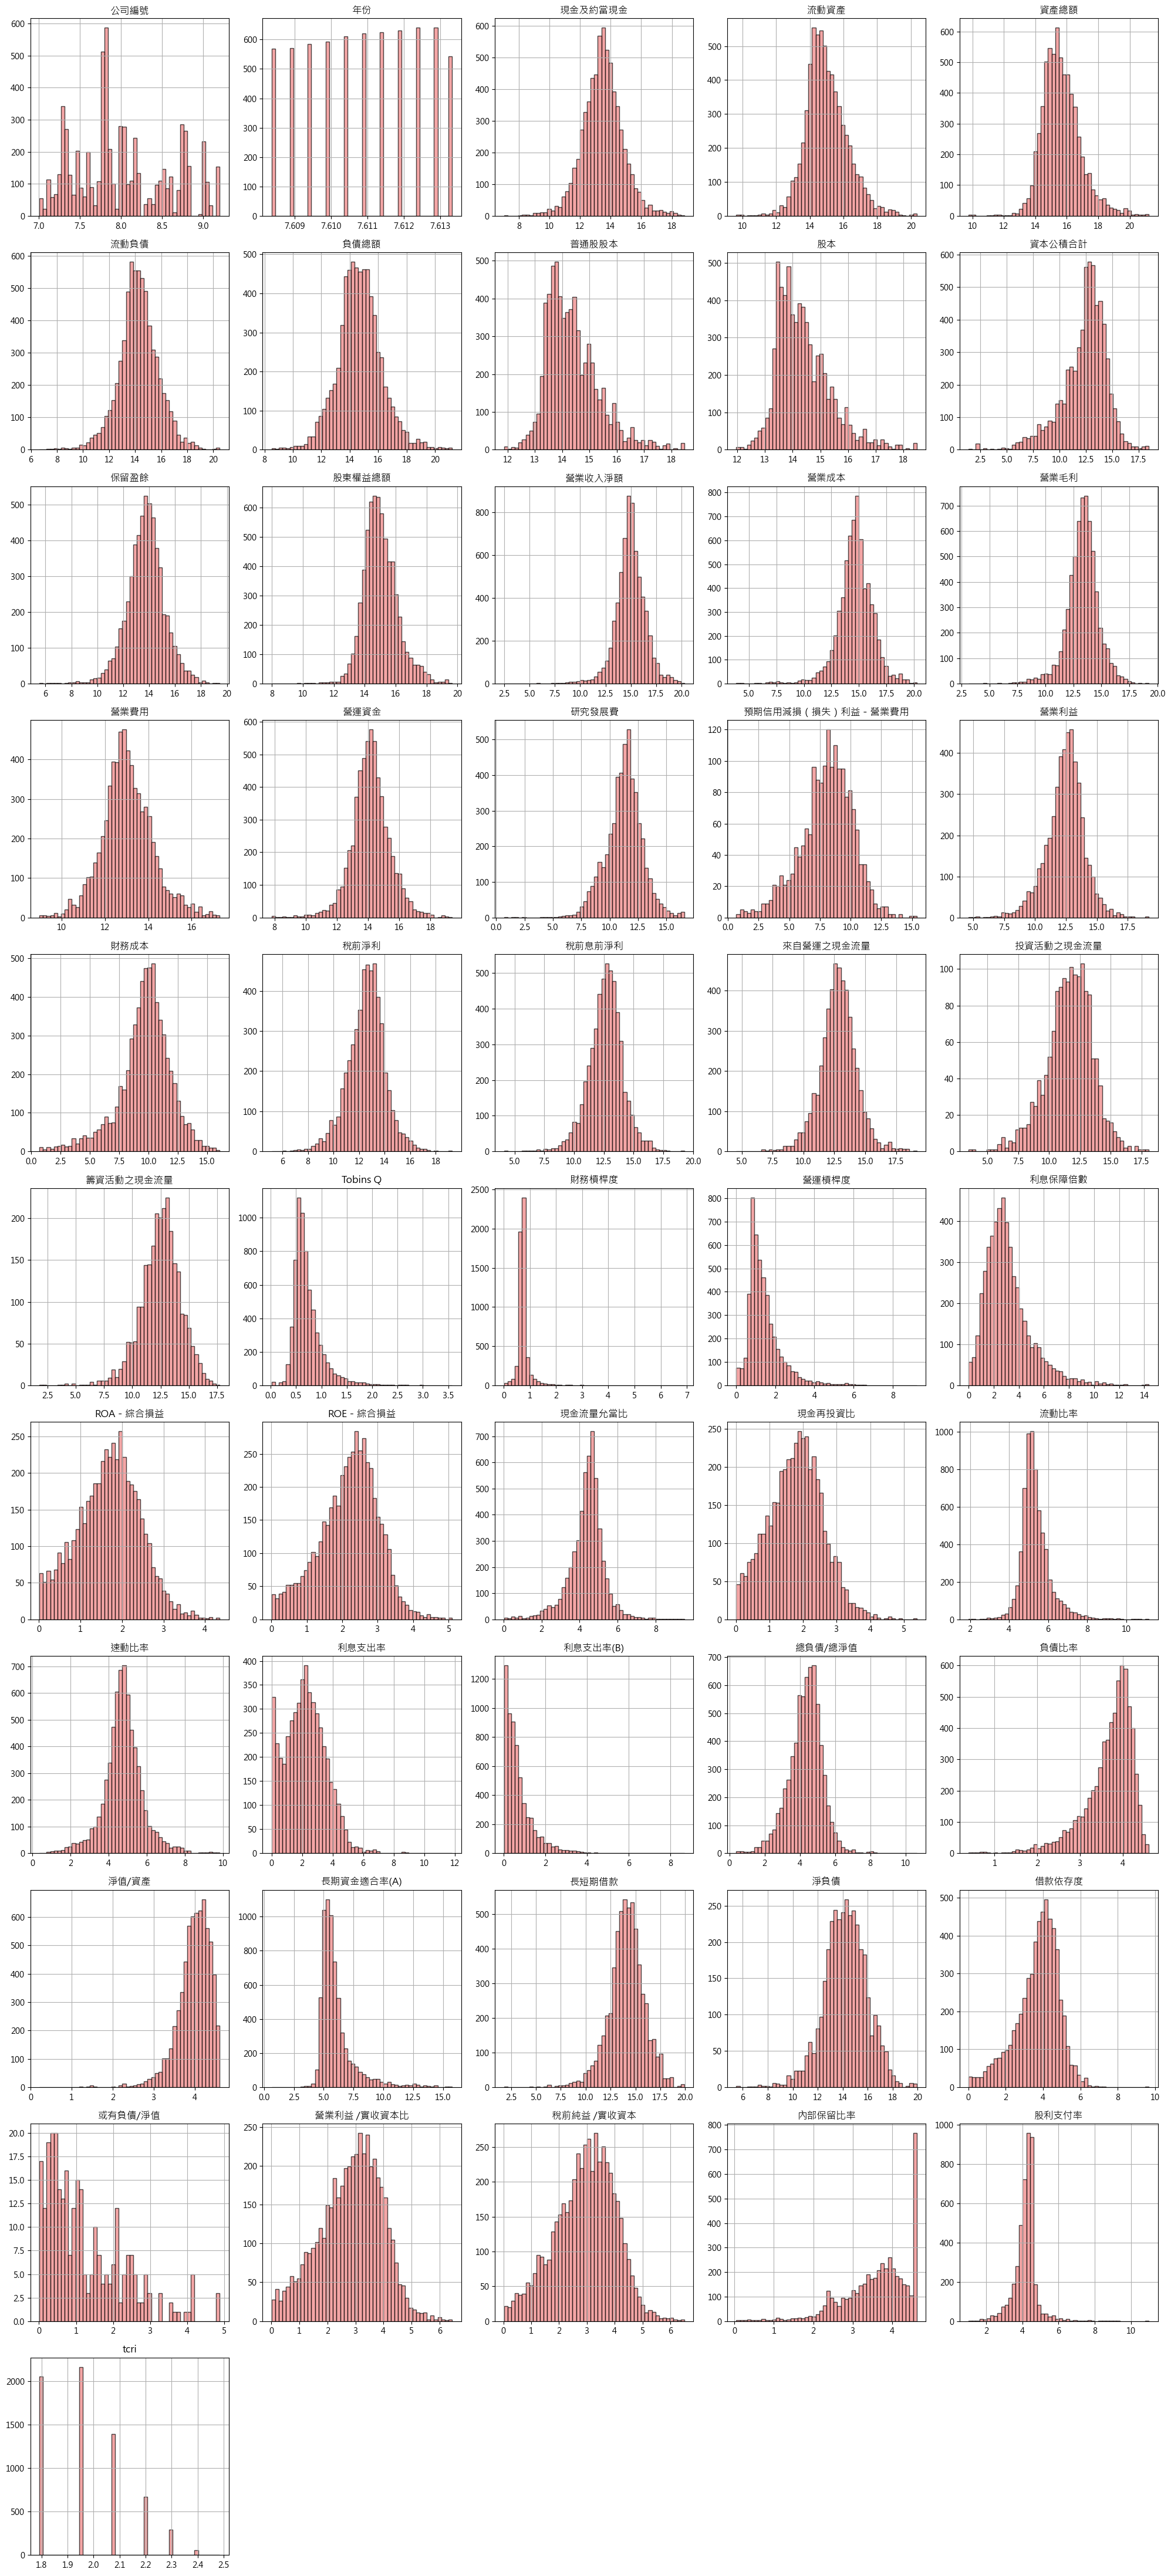

In [23]:
log_data = data.applymap(lambda x: np.log(x + 1) if x > 0 else np.nan)

n_features = len(log_data.columns)
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols

log_data.hist(
    figsize=(20, 4 * n_rows),
    bins=50,
    color='lightcoral',
    edgecolor='black',
    alpha=0.7,
    layout=(n_rows, n_cols)
)

plt.tight_layout()
plt.savefig('ln_histogram.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

### (test log_data)

In [30]:
log_data

,公司編號,年份,現金及約當現金,流動資產,資產總額,流動負債,負債總額,普通股股本,股本,資本公積合計,...,長期資金適合率(A),長短期借款,淨負債,借款依存度,或有負債/淨值,營業利益 /實收資本比,稅前純益 /實收資本,內部保留比率,股利支付率,tcri
0,7.01,7.61,14.97,16.37,17.33,15.03,16.48,15.87,15.87,13.25,...,6.83,16.26,14.90,4.11,NaN,NaN,0.11,NaN,7.26,1.95
1,7.01,7.61,14.42,16.18,17.13,14.24,16.41,15.87,15.87,13.31,...,6.94,16.21,15.44,4.37,1.40,1.83,1.26,4.19,3.58,1.95
2,7.01,7.61,14.67,16.06,17.08,14.50,16.15,15.86,15.86,13.33,...,7.02,15.88,14.84,3.93,1.27,NaN,0.70,NaN,6.44,1.95
3,7.01,7.61,14.41,16.02,17.16,14.66,16.02,15.86,15.86,13.37,...,6.75,15.77,14.59,3.62,1.17,NaN,2.71,4.06,3.79,1.95
4,7.01,7.61,14.49,16.23,17.28,14.98,16.22,15.86,15.86,13.46,...,6.66,15.86,14.43,3.64,1.11,NaN,1.87,NaN,4.71,1.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6619,9.21,7.61,14.23,15.72,16.67,15.22,15.94,14.60,14.65,14.88,...,5.12,14.77,11.92,3.40,NaN,3.96,3.92,2.40,4.51,1.79
6620,9.21,7.61,14.21,16.20,17.11,15.80,16.64,14.65,14.65,14.90,...,5.19,16.03,15.73,4.52,NaN,4.34,4.43,3.83,4.03,1.79
6621,9.21,7.61,14.09,16.28,17.20,15.97,16.77,14.66,14.66,14.93,...,4.96,16.16,15.79,4.63,NaN,1.61,2.09,4.24,3.48,1.79
6622,9.21,7.61,14.51,16.48,17.39,15.95,16.90,14.67,14.68,15.18,...,5.01,16.48,16.13,4.66,NaN,4.43,4.28,3.39,4.28,1.79


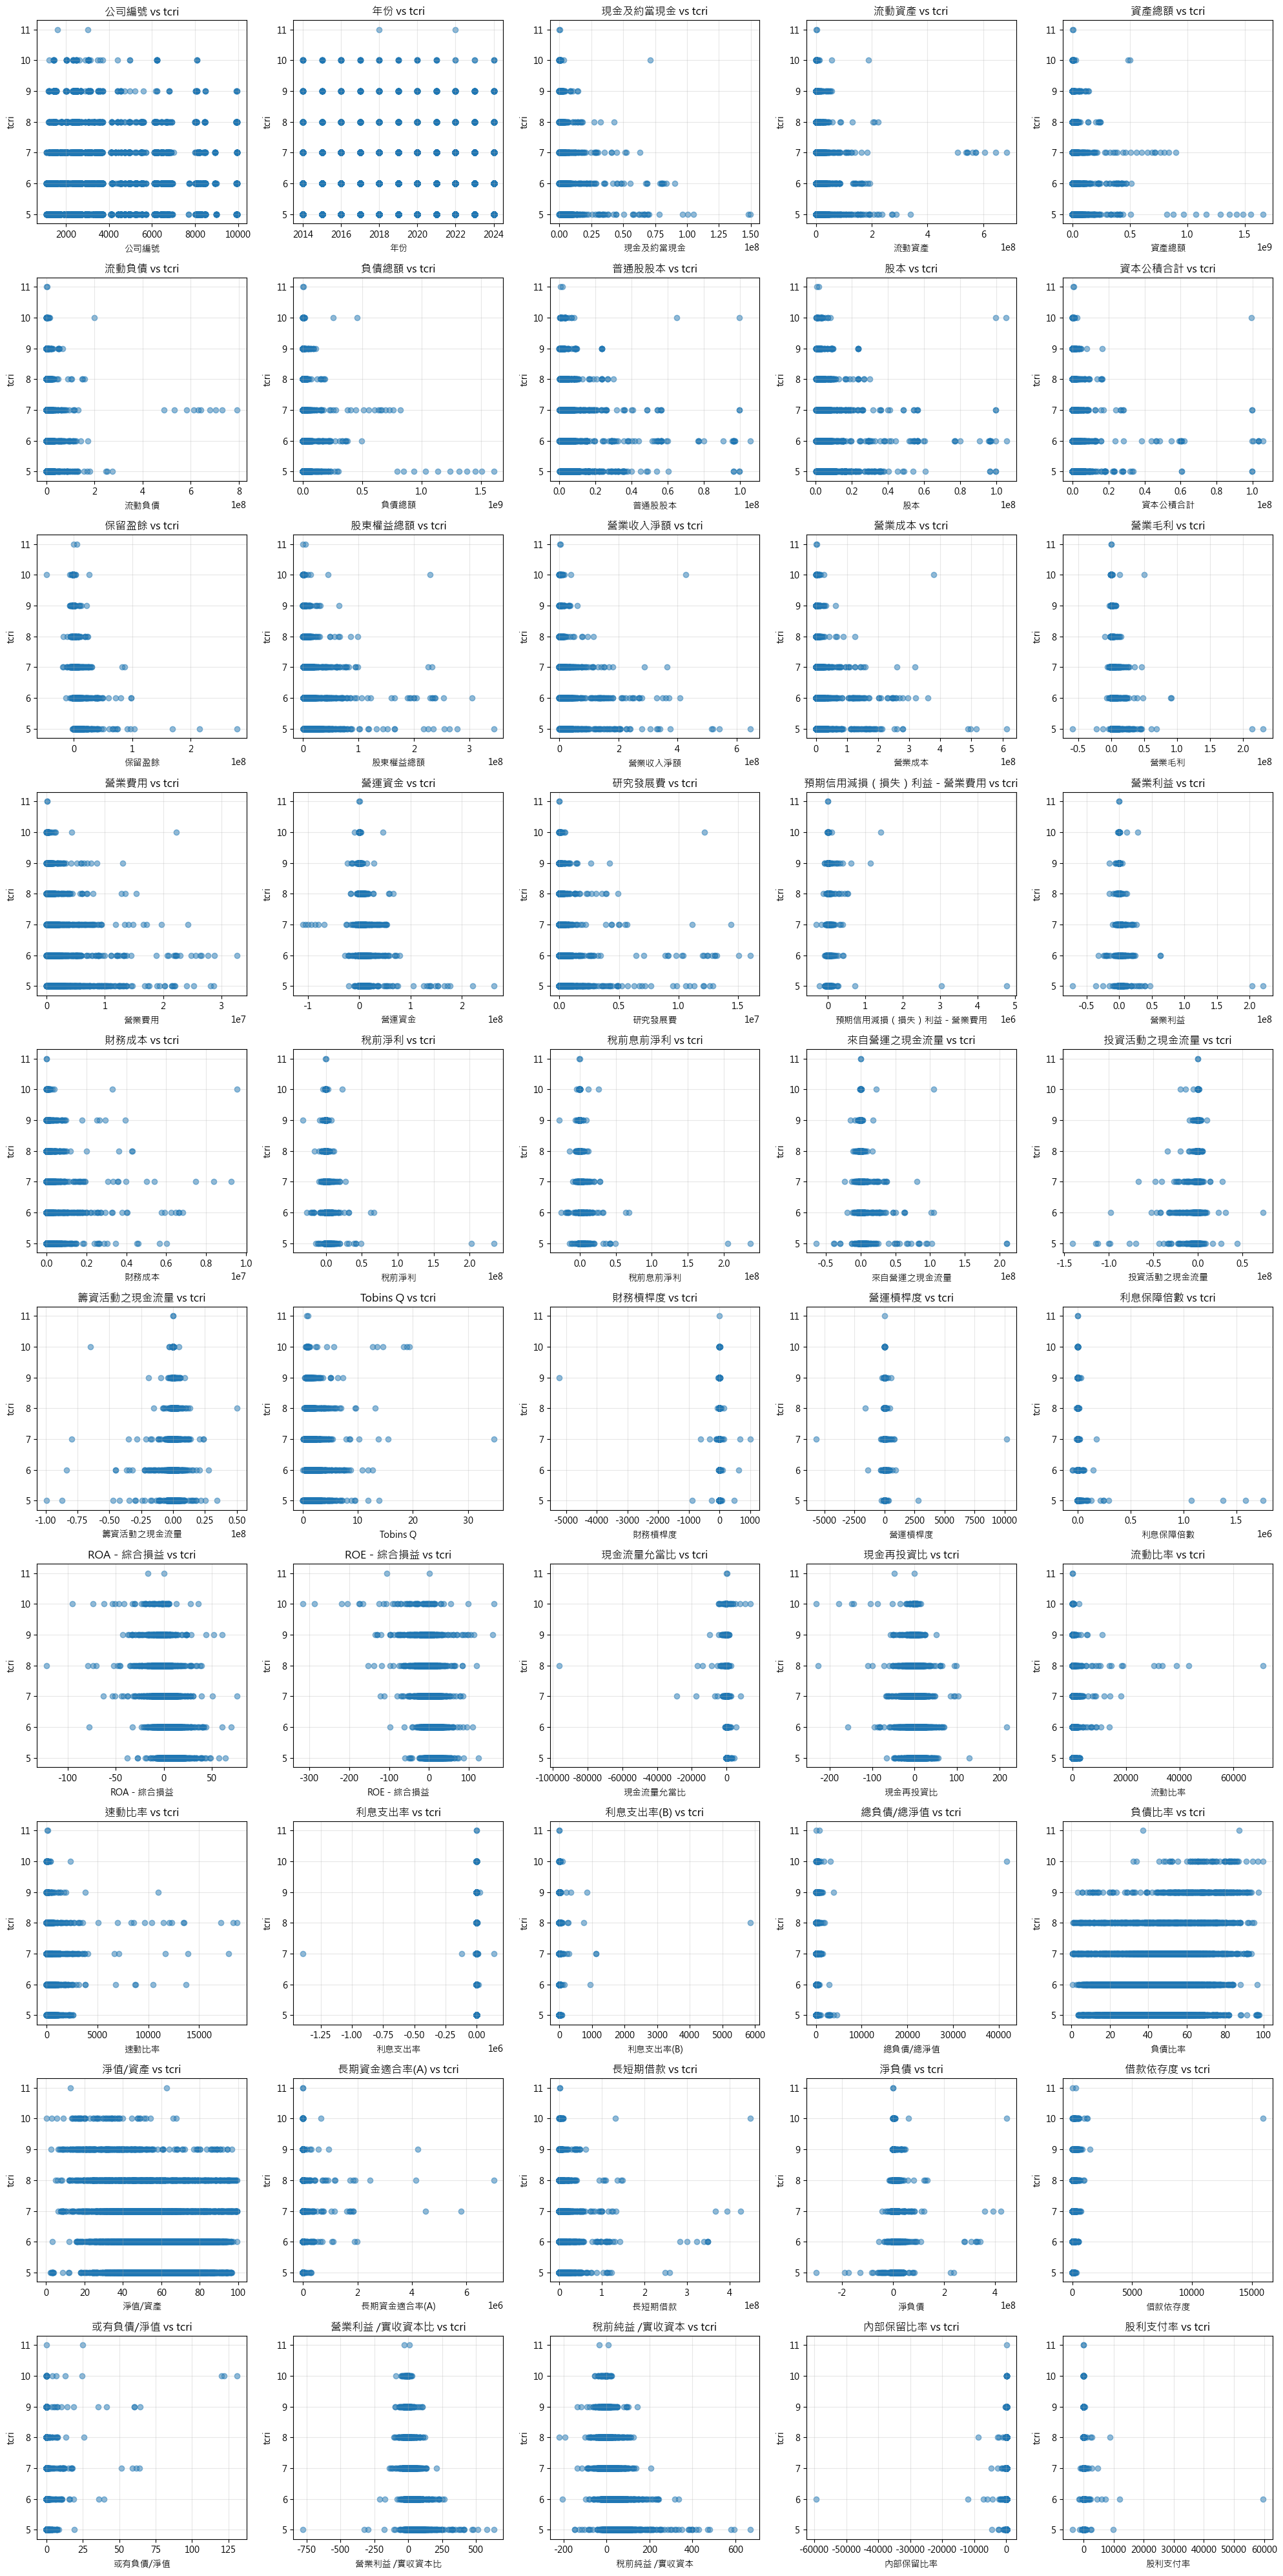

In [24]:
predictors = data.columns.drop('tcri')

n_features = len(predictors)
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(predictors):
    axes[i].scatter(data[feature], data['tcri'], alpha=0.5)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('tcri')
    axes[i].set_title(f'{feature} vs tcri')
    axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('scatter plot.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

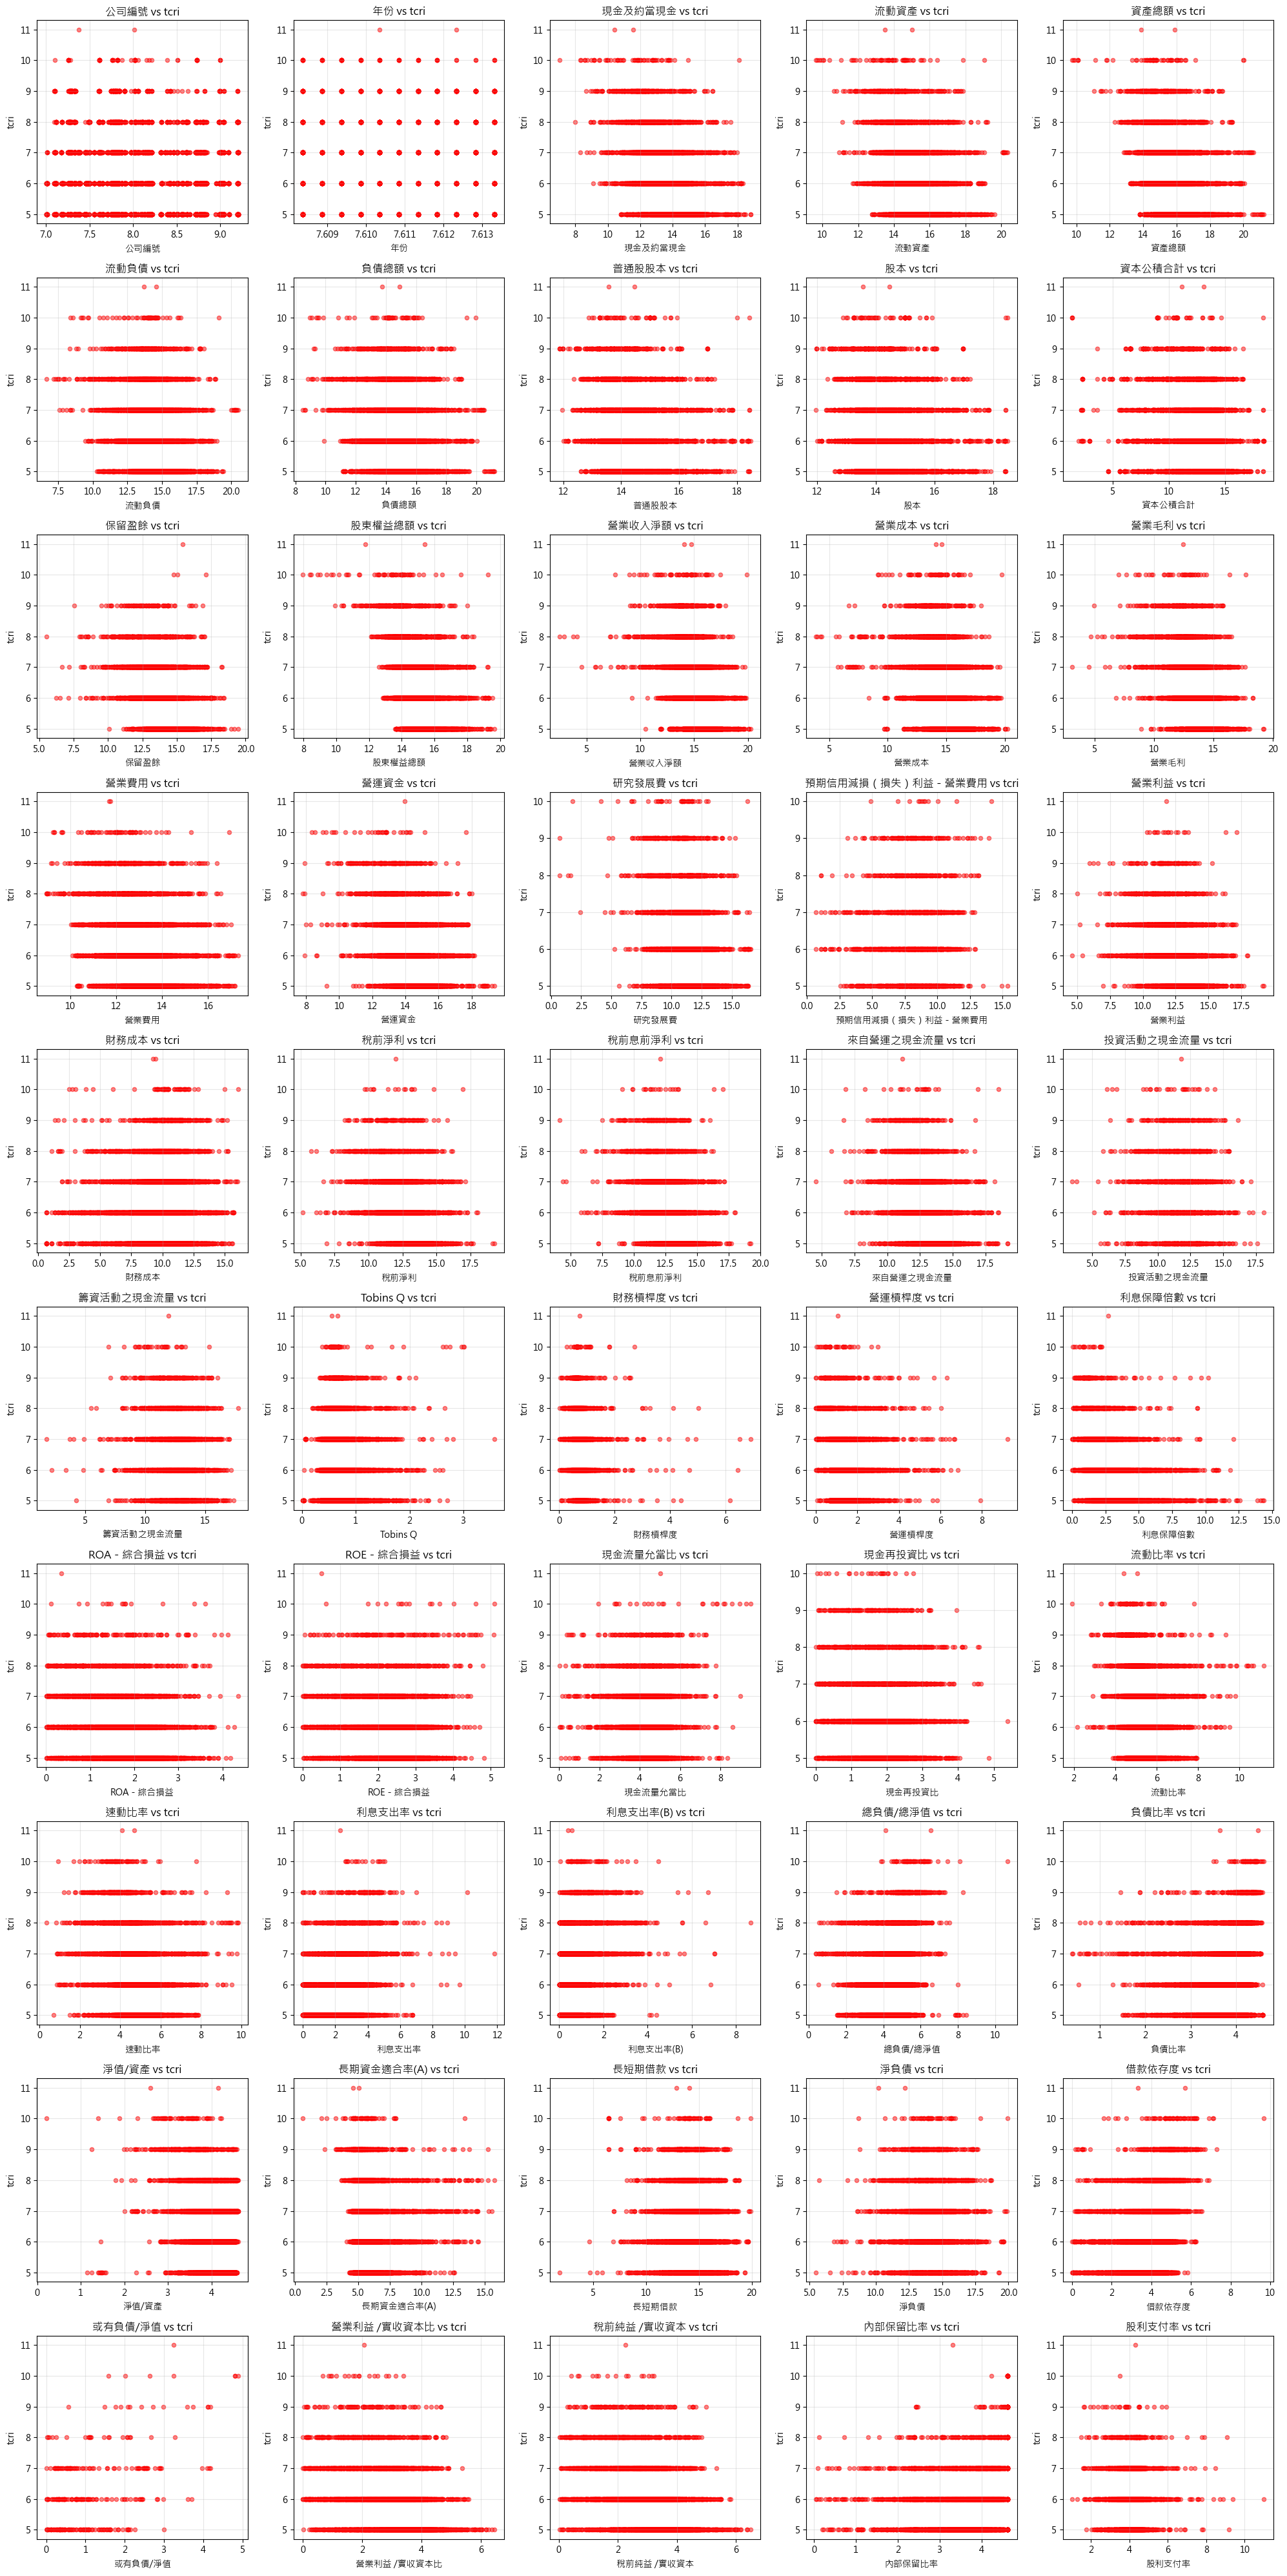

In [27]:
predictors = log_data.columns.drop('tcri')

ln_features = [f'{feature}' for feature in predictors]
n_cols = 5
n_rows = (len(ln_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, ln_feature in enumerate(ln_features):
    axes[i].scatter(log_data[ln_feature], data['tcri'], alpha=0.5, s=20, color='red')
    axes[i].set_xlabel(ln_feature)
    axes[i].set_ylabel('tcri')
    axes[i].set_title(f'{ln_feature} vs tcri')
    axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('ln scatter plot.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

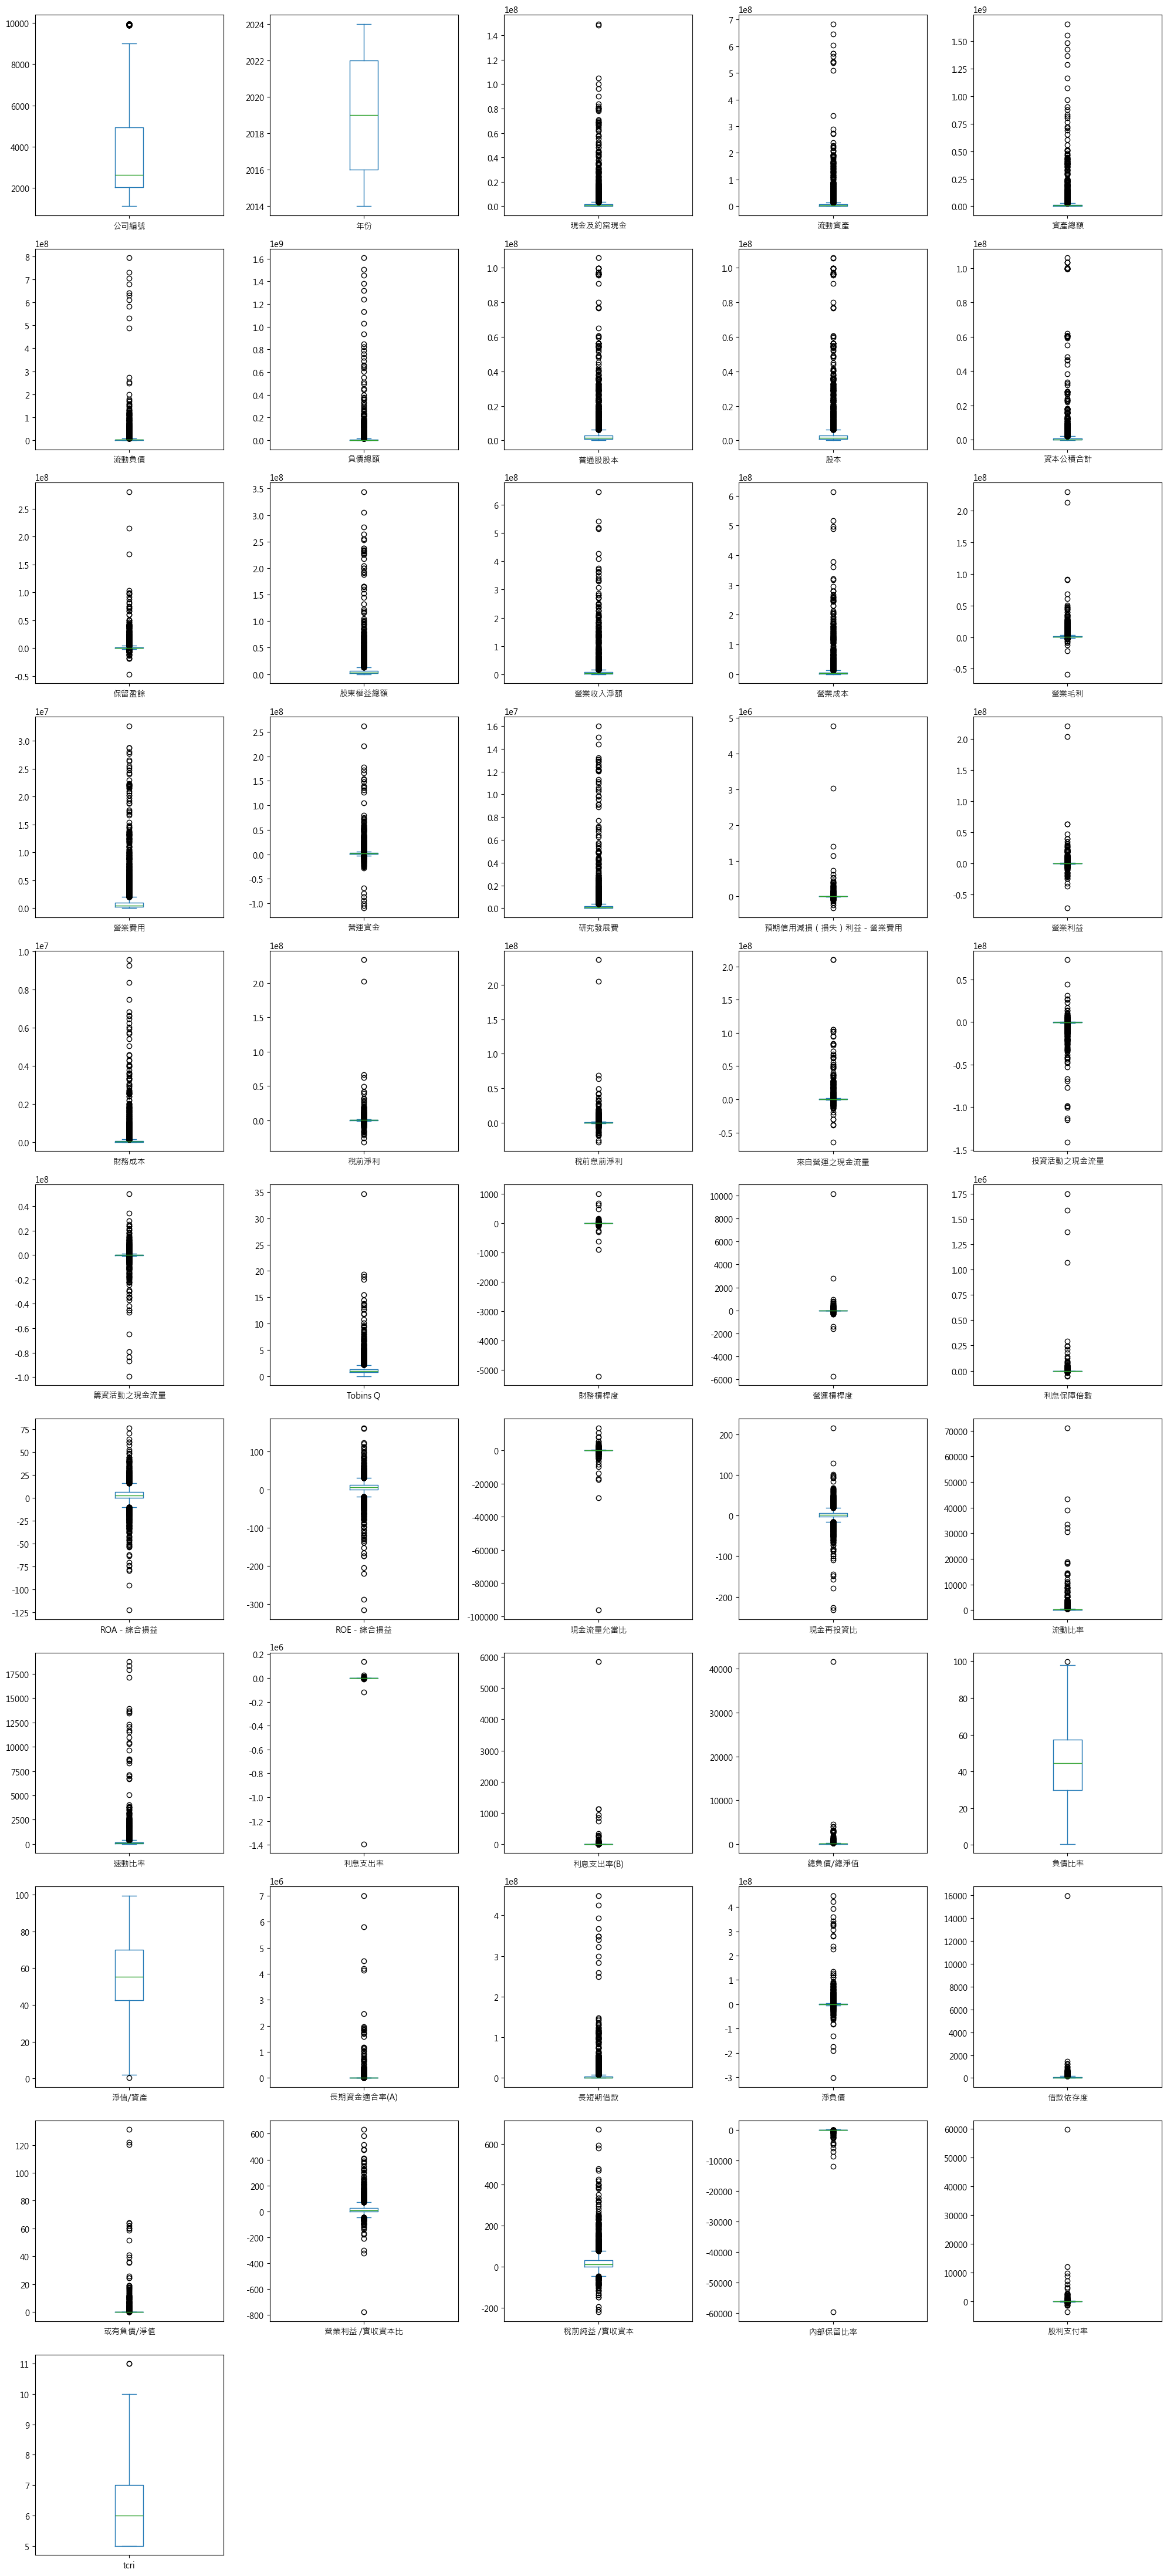

In [28]:
n_cols = 5
n_rows = (len(data.columns) + n_cols - 1) // n_cols

data.plot.box(
    figsize=(20, 4 * n_rows),
    layout=(n_rows, n_cols),
    subplots=True,
    vert=True
)

plt.tight_layout()
plt.savefig('box plot.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

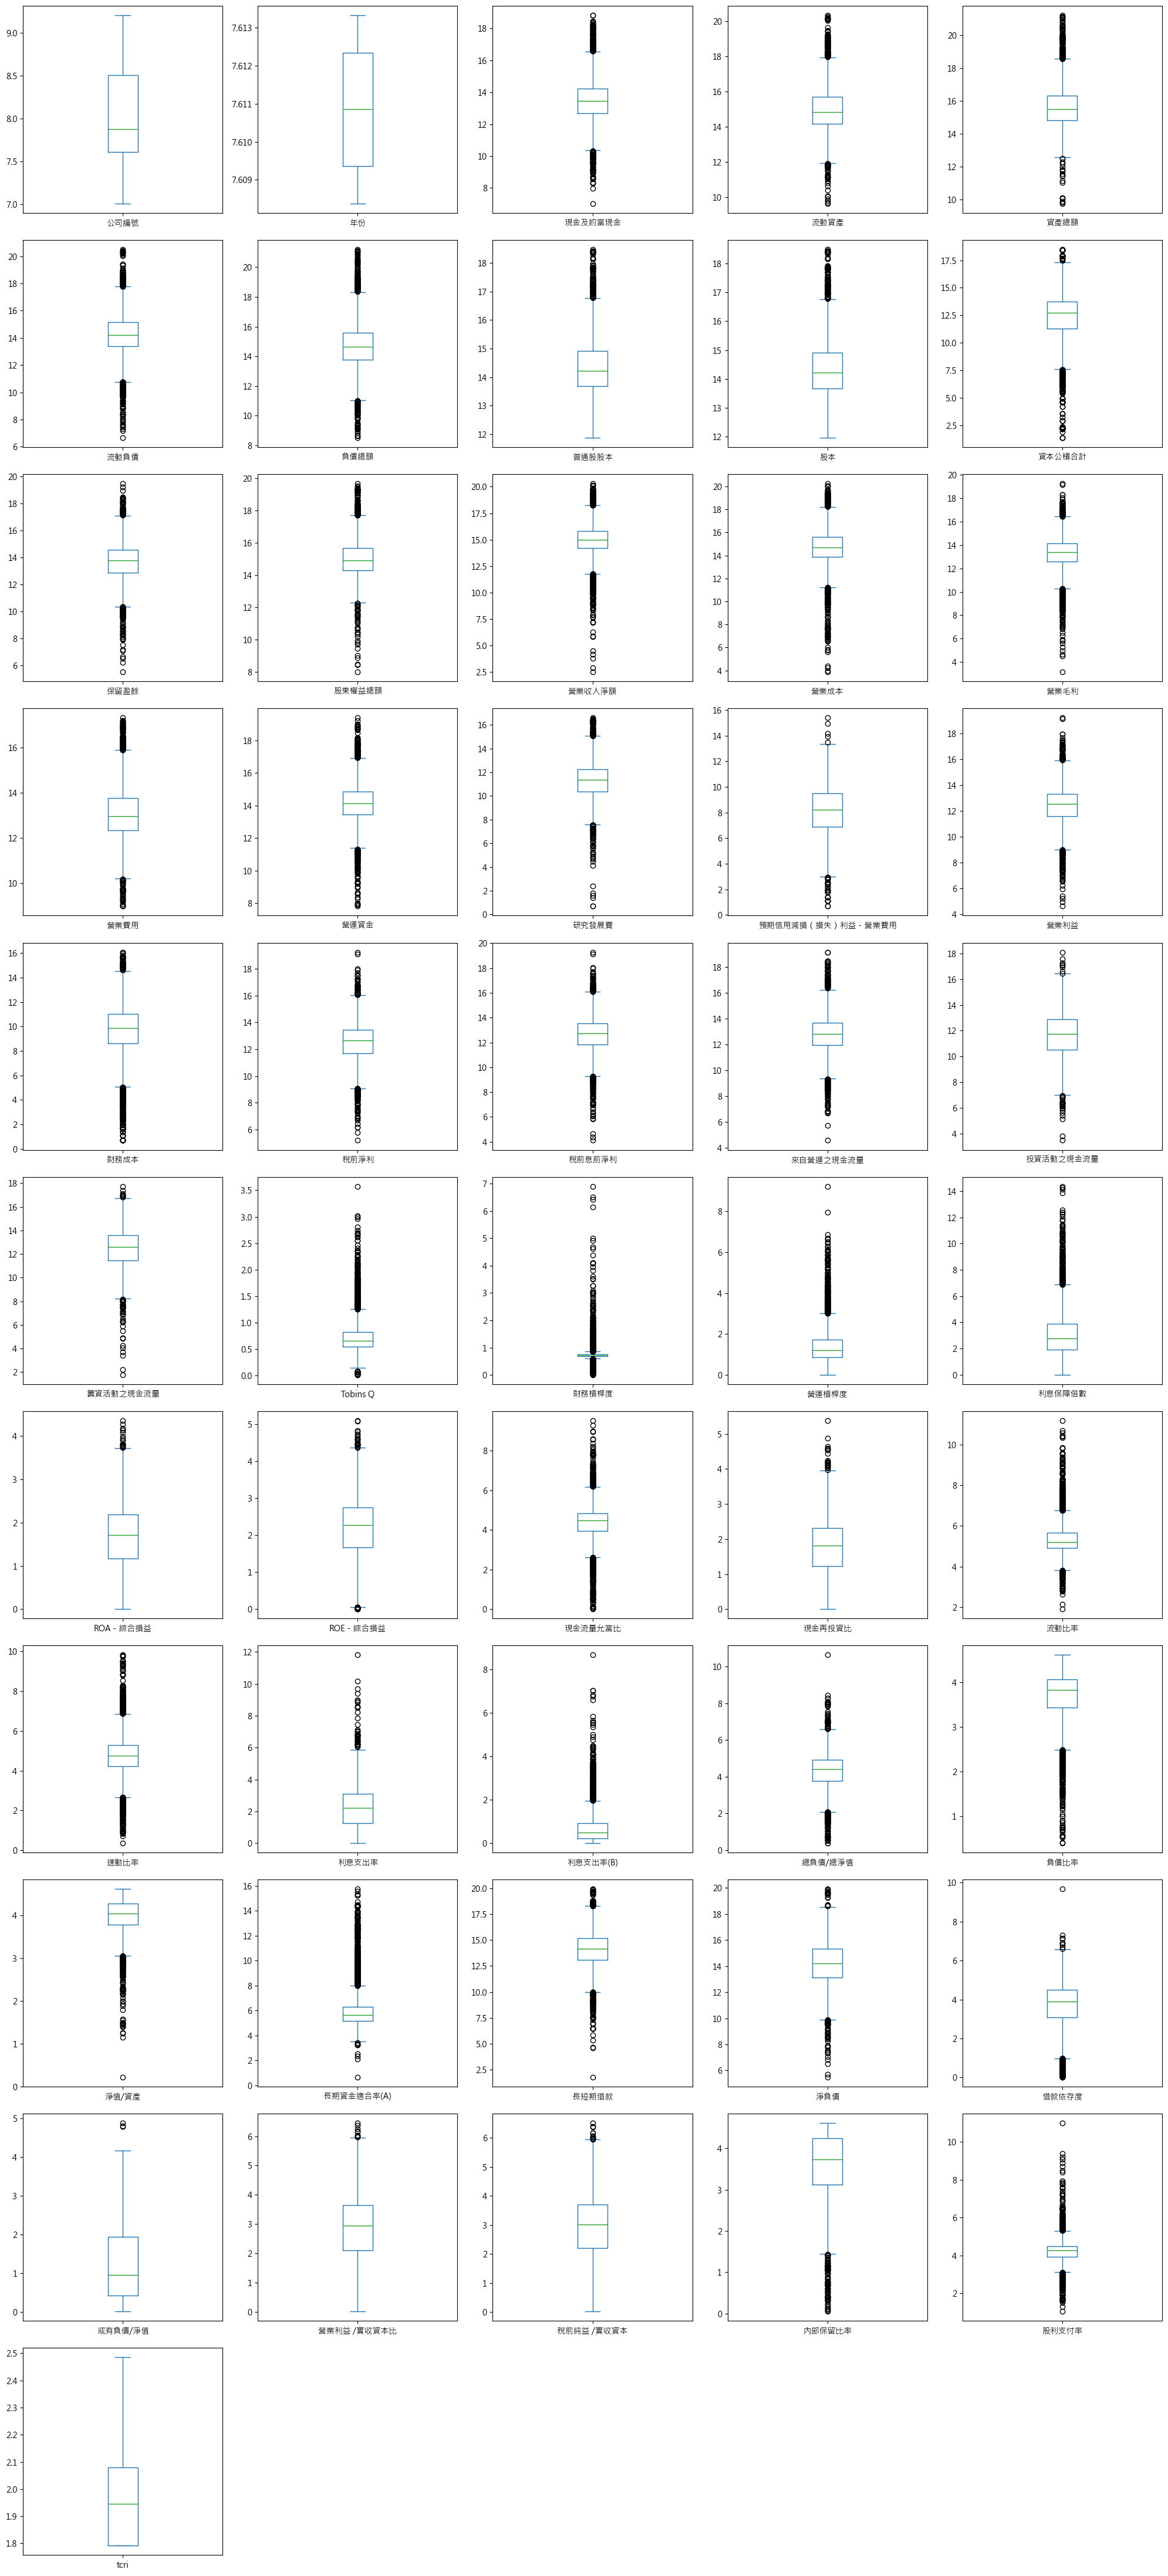

In [29]:
n_features = len(log_data.columns)
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols

log_data.plot.box(
    figsize=(20, 4 * n_rows),
    layout=(n_rows, n_cols),
    subplots=True,
    vert=True
)

plt.tight_layout()
plt.savefig('ln box plot.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()